# Exploratory Data Analysis

This notebook explores sales, profit, product, regional, and delivery performance using the processed order-item dataset produced by `01_data_preparation_and_quality.ipynb`.

Commercial analyses use the order-item table because sales, quantity, category, and item profit are recorded at that level. Delivery analyses use a separate order-level table with one row per `Order Id`, preventing multi-item orders from being counted more than once.

## Business Questions

1. What are the main sales and profit results?
2. How do sales and profit change over time?
3. Which regions and categories perform best?
4. Where are delivery delays most common at the order level?
5. Which order items generate losses?
6. Does average total order profit differ between delayed and on-time orders?


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.style.use("seaborn-v0_8-whitegrid")

# Locate the project root whether this notebook is run from the project root
# or from the notebooks directory.
current_path = Path.cwd().resolve()
if (current_path / "data").exists():
    project_root = current_path
elif (current_path.parent / "data").exists():
    project_root = current_path.parent
else:
    raise FileNotFoundError(
        "Project root could not be located. Run this notebook from the "
        "project root or the notebooks directory."
    )

figures_dir = project_root / "docs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

## 1. Load the Data

Each row represents one order item. The same order can therefore appear in more than one row.

In [2]:
data_path = project_root / "data" / "processed" / "dataco_cleaned.csv"

if not data_path.exists():
    raise FileNotFoundError(
        f"Processed dataset not found: {data_path}\n"
        "Run 01_data_preparation_and_quality.ipynb first."
    )

df = pd.read_csv(
    data_path,
    low_memory=False,
    parse_dates=[
        "order date (DateOrders)",
        "shipping date (DateOrders)",
    ],
)

print(f"Loaded file: {data_path}")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Orders: {df['Order Id'].nunique():,}")

Loaded file: C:\Users\Nothing\Downloads\newgithubprojects\dataco-supplychain-analytics\data\processed\dataco_cleaned.csv
Rows: 180,519
Columns: 64
Orders: 65,752


## 2. Validate the Processed Dataset and Create an Order-Level Table

The analytical columns below must already exist. They are created once during Python data preparation and are not recreated in this EDA notebook.

The source remains at the order-item level for commercial analysis. For delivery analysis, the notebook verifies that order-level shipping attributes are consistent within each `Order Id`, then creates `orders_df` with one row per order. Item profits are summed to produce `Total_Order_Profit`.


In [3]:
required_columns = [
    "Order Id",
    "Order Item Id",
    "Order Profit Per Order",
    "Order Region",
    "Shipping Mode",
    "schedule_variance_days",
    "is_canceled",
    "is_delayed",
    "delivery_timing",
    "loss_amount",
]

missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(
        "The processed dataset is missing these columns: "
        + ", ".join(missing_columns)
    )

assert len(df) == 180_519, f"Unexpected row count: {len(df):,}"
assert df["Order Id"].nunique() == 65_752, "Unexpected number of unique orders."

# These attributes must have one value within each order before rows are collapsed.
order_level_attributes = [
    "Order Region",
    "Shipping Mode",
    "schedule_variance_days",
    "is_canceled",
    "is_delayed",
    "delivery_timing",
]

inconsistent_attributes = {
    column: int((df.groupby("Order Id")[column].nunique(dropna=False) > 1).sum())
    for column in order_level_attributes
}
inconsistent_attributes = {
    column: count for column, count in inconsistent_attributes.items() if count > 0
}

if inconsistent_attributes:
    raise ValueError(
        "Order-level attributes are inconsistent within some orders: "
        f"{inconsistent_attributes}"
    )

orders_df = (
    df.groupby("Order Id", as_index=False)
    .agg(
        Order_Region=("Order Region", "first"),
        Shipping_Mode=("Shipping Mode", "first"),
        Schedule_Variance_Days=("schedule_variance_days", "first"),
        Is_Canceled=("is_canceled", "first"),
        Is_Delayed=("is_delayed", "first"),
        Delivery_Timing=("delivery_timing", "first"),
        Order_Item_Count=("Order Item Id", "count"),
        Total_Order_Profit=("Order Profit Per Order", "sum"),
    )
)

assert len(orders_df) == df["Order Id"].nunique()
assert orders_df["Order Id"].is_unique
assert abs(orders_df["Total_Order_Profit"].sum() - df["Order Profit Per Order"].sum()) < 0.01

print("Processed dataset validation passed.")
print(f"Order-item rows: {len(df):,}")
print(f"Unique orders: {len(orders_df):,}")
display(orders_df.head())


Processed dataset validation passed.
Order-item rows: 180,519
Unique orders: 65,752


,Order Id,Order_Region,Shipping_Mode,Schedule_Variance_Days,Is_Canceled,Is_Delayed,Delivery_Timing,Order_Item_Count,Total_Order_Profit
0,1,Central America,Standard Class,-2,0,0,Not delayed,1,88.79
1,2,South America,Standard Class,-1,0,0,Not delayed,3,195.90
2,4,South America,Standard Class,1,0,1,Delayed,4,124.09
3,5,South America,Standard Class,2,0,1,Delayed,5,390.09
4,7,South America,Second Class,1,0,1,Delayed,3,203.93


## 3. Overall Performance

Sales, profit, and loss KPIs are measured at the order-item level. Delivery KPIs are measured at the unique-order level, with canceled orders excluded from the delay-rate denominator.


In [4]:
total_sales = df["Sales"].sum()
total_profit = df["Order Profit Per Order"].sum()
profit_margin = total_profit / total_sales * 100
total_items = len(df)
total_orders = len(orders_df)

canceled_orders = int(orders_df["Is_Canceled"].sum())
shipped_orders_count = total_orders - canceled_orders
delayed_orders = int(
    orders_df.loc[orders_df["Is_Canceled"] == 0, "Is_Delayed"].sum()
)
on_time_orders = shipped_orders_count - delayed_orders
delay_rate = delayed_orders / shipped_orders_count * 100

loss_items = int((df["Order Profit Per Order"] < 0).sum())
loss_rate = loss_items / total_items * 100

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total sales",
        "Total profit",
        "Profit margin (%)",
        "Order items",
        "Unique orders",
        "Canceled orders",
        "Delayed orders",
        "On-time orders",
        "Delay rate among non-canceled orders (%)",
        "Loss-making items",
        "Loss-making item rate (%)",
    ],
    "Value": [
        total_sales,
        total_profit,
        profit_margin,
        total_items,
        total_orders,
        canceled_orders,
        delayed_orders,
        on_time_orders,
        delay_rate,
        loss_items,
        loss_rate,
    ],
})

display(kpi_summary)

# Stable commercial reference totals from the processed dataset.
assert round(total_sales, 2) == 36_784_735.01
assert round(total_profit, 2) == 3_966_902.97
assert delayed_orders + on_time_orders == shipped_orders_count
print("Reference KPI validation passed.")


,Metric,Value
0,Total sales,"36,784,735.01"
1,Total profit,"3,966,902.97"
2,Profit margin (%),10.78
3,Order items,"180,519.00"
4,Unique orders,"65,752.00"
5,Canceled orders,"2,855.00"
6,Delayed orders,"36,048.00"
7,On-time orders,"26,849.00"
8,Delay rate among non-canceled orders (%),57.31
9,Loss-making items,"33,784.00"


Reference KPI validation passed.


## 4. Monthly Sales and Profit

Monthly results show whether business performance is growing, declining, or changing over time.

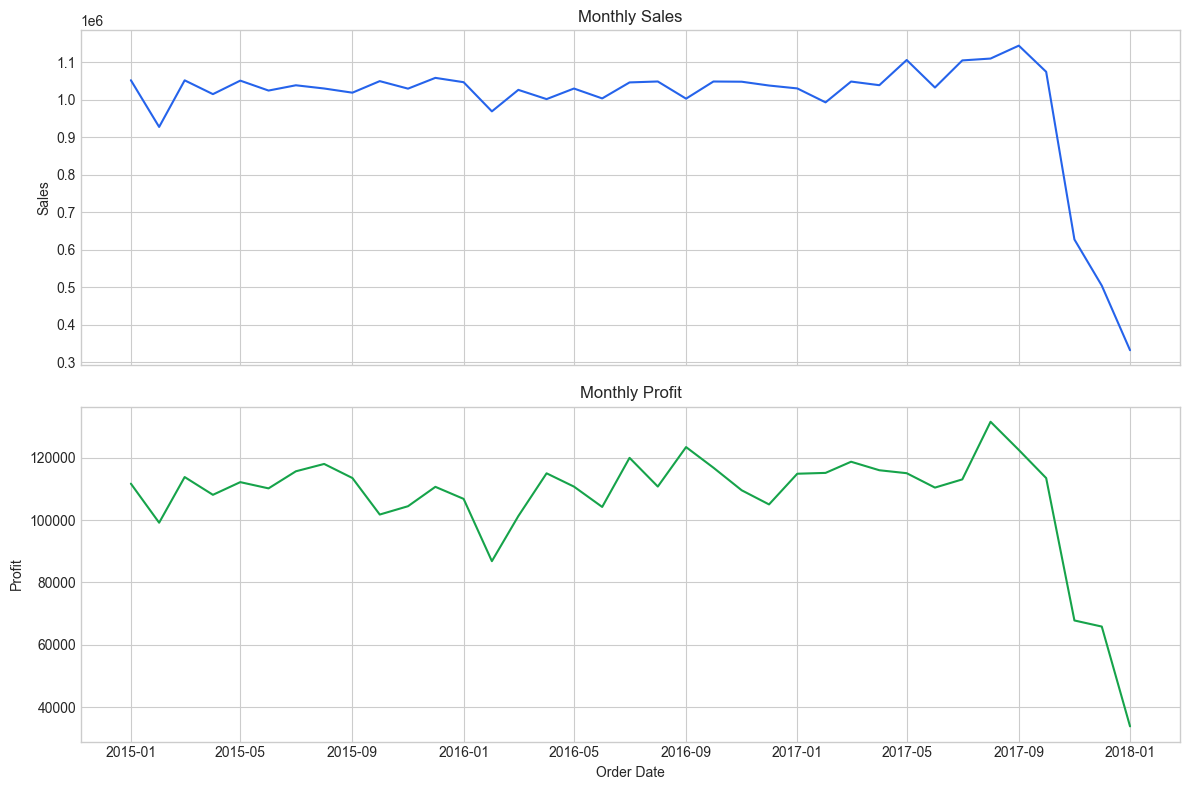

In [5]:
monthly_performance = (
    df.groupby(df["order date (DateOrders)"].dt.to_period("M"))
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Order Profit Per Order", "sum")
      )
      .reset_index()
)

monthly_performance["order date (DateOrders)"] = (
    monthly_performance["order date (DateOrders)"].dt.to_timestamp()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(
    monthly_performance["order date (DateOrders)"],
    monthly_performance["Sales"],
    color="#2563eb"
)
axes[0].set_title("Monthly Sales")
axes[0].set_ylabel("Sales")

axes[1].plot(
    monthly_performance["order date (DateOrders)"],
    monthly_performance["Profit"],
    color="#16a34a"
)
axes[1].set_title("Monthly Profit")
axes[1].set_ylabel("Profit")
axes[1].set_xlabel("Order Date")

plt.tight_layout()
plt.savefig(figures_dir / "monthly_sales_and_profit.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Regional Performance

This comparison identifies the regions with the highest sales and shows whether their profits follow the same pattern.

,Order Region,Sales,Profit,Order_Items,Profit Margin (%)
0,Western Europe,"5,894,380.77","625,446.08",27109,10.61
1,Central America,"5,665,712.10","616,341.57",28341,10.88
2,South America,"2,960,881.41","335,154.40",14935,11.32
3,Northern Europe,"2,155,830.65","233,450.60",9792,10.83
4,Southern Europe,"2,047,918.82","230,829.23",9431,11.27
5,Oceania,"2,016,654.20","201,478.02",10148,9.99
6,Southeast Asia,"1,932,495.57","211,342.82",9539,10.94
7,Caribbean,"1,651,019.33","171,825.64",8318,10.41
8,West of USA,"1,571,415.96","164,940.66",7993,10.50
9,South Asia,"1,553,680.92","165,703.90",7731,10.67


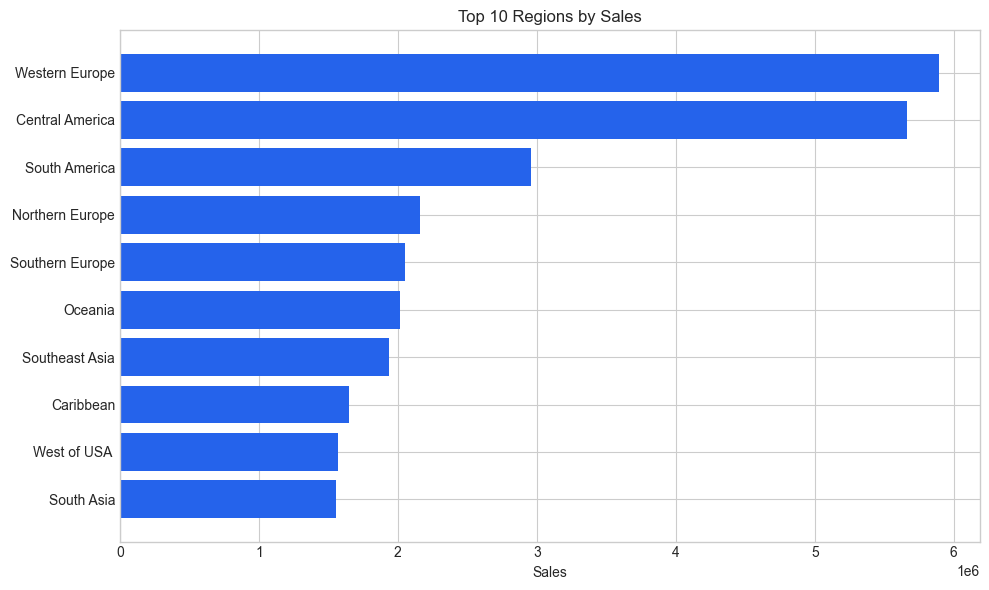

In [6]:
region_performance = (
    df.groupby("Order Region")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Order Profit Per Order", "sum"),
          Order_Items=("Order Item Id", "count")
      )
      .sort_values("Sales", ascending=False)
      .reset_index()
)

region_performance["Profit Margin (%)"] = (
    region_performance["Profit"] / region_performance["Sales"] * 100
)

display(region_performance.head(10))

top_regions = region_performance.head(10).sort_values("Sales")

plt.figure(figsize=(10, 6))
plt.barh(top_regions["Order Region"], top_regions["Sales"], color="#2563eb")
plt.title("Top 10 Regions by Sales")
plt.xlabel("Sales")
plt.ylabel("")
plt.tight_layout()
plt.savefig(figures_dir / "top_regions_by_sales.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Category Performance

High sales do not always mean high profit. This table compares both measures for the leading product categories.

,Category Name,Sales,Profit,Quantity,Profit Margin (%)
0,Fishing,"6,929,653.69","756,220.77",17325,10.91
1,Cleats,"4,431,942.78","494,636.92",73734,11.16
2,Camping & Hiking,"4,118,425.57","427,455.57",13729,10.38
3,Cardio Equipment,"3,694,843.20","383,011.10",37587,10.37
4,Women's Apparel,"3,147,800.00","350,421.03",62956,11.13
5,Water Sports,"3,113,844.68","325,146.96",15540,10.44
6,Men's Footwear,"2,891,757.66","311,902.82",22246,10.79
7,Indoor/Outdoor Games,"2,888,993.91","318,451.43",57803,11.02
8,Shop By Sport,"1,309,522.04","129,813.96",32726,9.91
9,Computers,"663,000.00","69,656.81",442,10.51


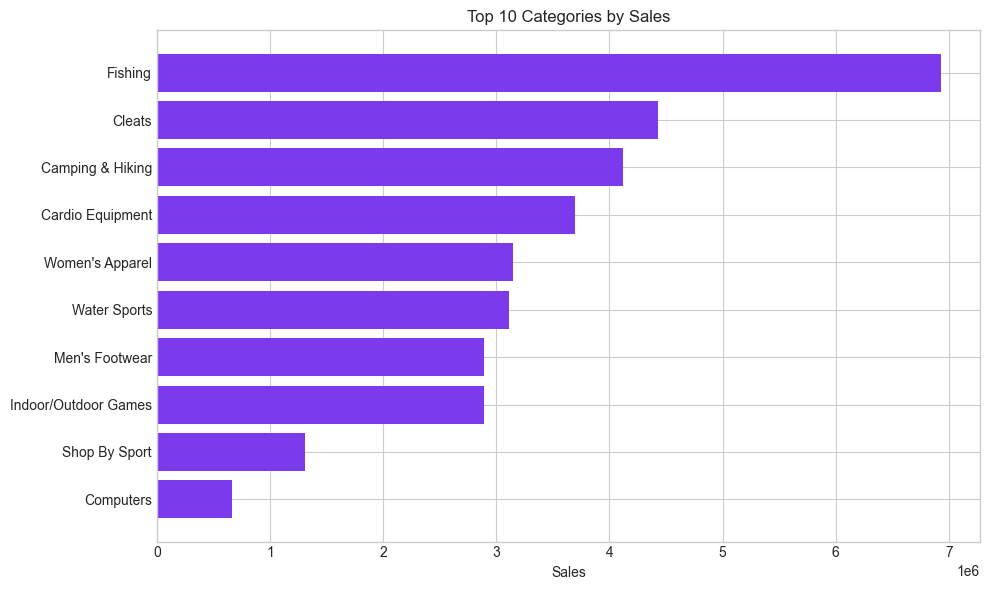

In [7]:
category_performance = (
    df.groupby("Category Name")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Order Profit Per Order", "sum"),
          Quantity=("Order Item Quantity", "sum")
      )
      .sort_values("Sales", ascending=False)
      .reset_index()
)

category_performance["Profit Margin (%)"] = (
    category_performance["Profit"] / category_performance["Sales"] * 100
)

display(category_performance.head(10))

top_categories = category_performance.head(10).sort_values("Sales")

plt.figure(figsize=(10, 6))
plt.barh(top_categories["Category Name"], top_categories["Sales"], color="#7c3aed")
plt.title("Top 10 Categories by Sales")
plt.xlabel("Sales")
plt.ylabel("")
plt.tight_layout()
plt.savefig(figures_dir / "top_categories_by_sales.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Delivery Performance at the Order Level

Each `Order Id` is counted once. Canceled orders are shown in the overall timing distribution but excluded from delay comparisons because they were not completed. An order is delayed when its actual shipping time exceeds its scheduled shipping time (`Schedule_Variance_Days > 0`).


,Delivery Timing,Orders,Rate (%)
0,Delayed,36048,54.82
1,Not delayed,26849,40.83
2,Canceled,2855,4.34


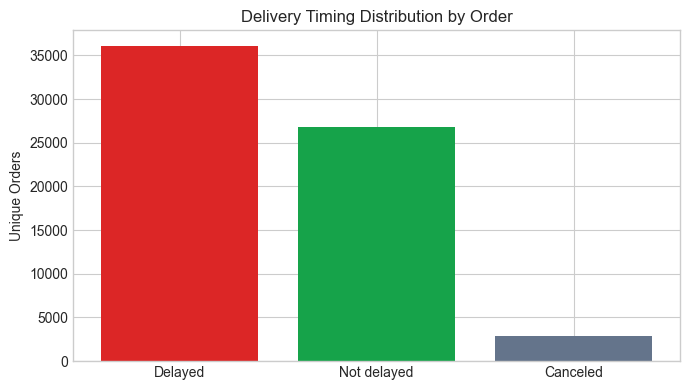

In [8]:
shipped_orders = orders_df[orders_df["Is_Canceled"] == 0].copy()

delivery_summary = (
    orders_df["Delivery_Timing"]
    .value_counts()
    .rename_axis("Delivery Timing")
    .reset_index(name="Orders")
)

delivery_summary["Rate (%)"] = delivery_summary["Orders"] / len(orders_df) * 100

display(delivery_summary)

plt.figure(figsize=(7, 4))
plt.bar(
    delivery_summary["Delivery Timing"],
    delivery_summary["Orders"],
    color=["#dc2626", "#16a34a", "#64748b"],
)
plt.title("Delivery Timing Distribution by Order")
plt.ylabel("Unique Orders")
plt.tight_layout()
plt.savefig(figures_dir / "delivery_timing_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### Order-Level Delay Rate by Shipping Mode

This view counts each order once and identifies shipping modes with the highest delay risk among non-canceled orders.


,Shipping_Mode,Orders,Delayed_Orders,Average_Schedule_Variance_Days,Delay Rate (%)
0,First Class,9602,9602,1.00,100.00
2,Second Class,12256,9803,2.00,79.99
1,Same Day,3407,1648,0.48,48.37
3,Standard Class,37632,14995,-0.01,39.85


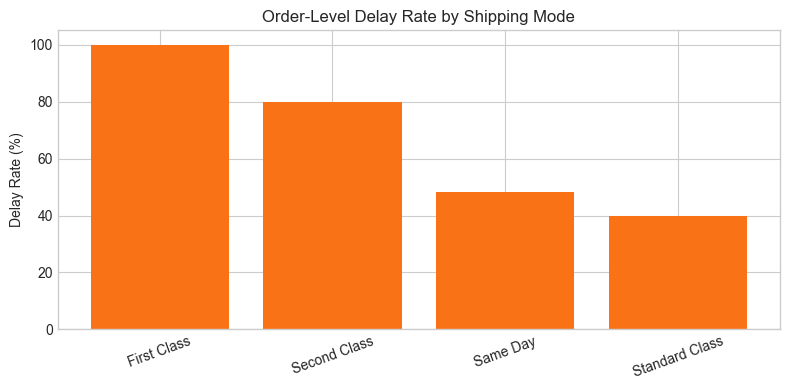

In [9]:
shipping_mode_summary = (
    shipped_orders.groupby("Shipping_Mode")
    .agg(
        Orders=("Order Id", "count"),
        Delayed_Orders=("Is_Delayed", "sum"),
        Average_Schedule_Variance_Days=("Schedule_Variance_Days", "mean"),
    )
    .reset_index()
)

shipping_mode_summary["Delay Rate (%)"] = (
    shipping_mode_summary["Delayed_Orders"]
    / shipping_mode_summary["Orders"]
    * 100
)

shipping_mode_summary = shipping_mode_summary.sort_values(
    "Delay Rate (%)", ascending=False
)

display(shipping_mode_summary)

plt.figure(figsize=(8, 4))
plt.bar(
    shipping_mode_summary["Shipping_Mode"],
    shipping_mode_summary["Delay Rate (%)"],
    color="#f97316",
)
plt.title("Order-Level Delay Rate by Shipping Mode")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(figures_dir / "delay_rate_by_shipping_mode.png", dpi=300, bbox_inches="tight")
plt.show()


### Regions with the Highest Order-Level Delay Rates

Only regions with at least 1,000 non-canceled orders are included, so very small groups do not distort the comparison.


In [10]:
region_delay = (
    shipped_orders.groupby("Order_Region")
    .agg(
        Orders=("Order Id", "count"),
        Delayed_Orders=("Is_Delayed", "sum"),
    )
    .reset_index()
)

region_delay["Delay Rate (%)"] = (
    region_delay["Delayed_Orders"] / region_delay["Orders"] * 100
)

region_delay = (
    region_delay[region_delay["Orders"] >= 1_000]
    .sort_values("Delay Rate (%)", ascending=False)
)

display(region_delay.head(10))


,Order_Region,Orders,Delayed_Orders,Delay Rate (%)
14,South of USA,1280,753,58.83
20,West Asia,1935,1132,58.50
22,Western Europe,9563,5585,58.40
8,Eastern Europe,1246,723,58.03
15,Southeast Asia,4173,2421,58.02
13,South Asia,3219,1865,57.94
18,US Center,1852,1071,57.83
6,East of USA,2219,1276,57.50
7,Eastern Asia,3171,1818,57.33
3,Central America,9001,5156,57.28


## 8. Loss-Making Order Items

This section measures how much negative-profit order items reduce overall profitability.

In [11]:
loss_orders = df[df["loss_amount"] > 0].copy()

loss_summary = pd.DataFrame({
    "Metric": [
        "Loss-making items",
        "Loss-making rate (%)",
        "Total loss amount",
        "Average loss per item"
    ],
    "Value": [
        len(loss_orders),
        len(loss_orders) / len(df) * 100,
        loss_orders["loss_amount"].sum(),
        loss_orders["loss_amount"].mean()
    ]
})

display(loss_summary)

category_losses = (
    loss_orders.groupby("Category Name")
    .agg(
        Loss_Items=("Order Item Id", "count"),
        Total_Loss=("loss_amount", "sum")
    )
    .sort_values("Total_Loss", ascending=False)
    .reset_index()
)

display(category_losses.head(10))

,Metric,Value
0,Loss-making items,"33,784.00"
1,Loss-making rate (%),18.71
2,Total loss amount,"3,883,547.35"
3,Average loss per item,114.95


,Category Name,Loss_Items,Total_Loss
0,Fishing,3209,"728,570.95"
1,Cleats,4590,"452,594.21"
2,Camping & Hiking,2590,"443,082.23"
3,Cardio Equipment,2332,"402,647.26"
4,Water Sports,2924,"334,569.63"
5,Women's Apparel,3923,"323,772.87"
6,Men's Footwear,4169,"309,269.70"
7,Indoor/Outdoor Games,3617,"298,637.48"
8,Shop By Sport,2154,"144,310.56"
9,Computers,73,"74,967.13"


## 9. Hypothesis Test: Delivery Delay and Total Order Profit

### Business question
Do delayed and on-time orders have different average total order profit?

### Unit of analysis
Each observation is one unique, non-canceled order. Profit from all items belonging to the same `Order Id` is summed into `Total_Order_Profit` before the comparison.

### Hypotheses
- **Null hypothesis ($H_0$):** Mean total order profit is equal for delayed and on-time orders.
- **Alternative hypothesis ($H_1$):** Mean total order profit differs between delayed and on-time orders.

A two-sided Welch's t-test is used because the two groups may have unequal variances and unequal sample sizes. The significance level is $\alpha = 0.05$.


In [12]:
alpha = 0.05

delayed_profit = shipped_orders.loc[
    shipped_orders["Is_Delayed"] == 1, "Total_Order_Profit"
].dropna()
on_time_profit = shipped_orders.loc[
    shipped_orders["Is_Delayed"] == 0, "Total_Order_Profit"
].dropna()

group_summary = pd.DataFrame({
    "Group": ["On time", "Delayed"],
    "Orders": [len(on_time_profit), len(delayed_profit)],
    "Mean total order profit": [on_time_profit.mean(), delayed_profit.mean()],
    "Standard deviation": [on_time_profit.std(), delayed_profit.std()],
})
display(group_summary)

test_result = ttest_ind(
    on_time_profit,
    delayed_profit,
    equal_var=False,
    nan_policy="omit",
)

# Standardized effect size using the pooled sample standard deviation.
n_on_time, n_delayed = len(on_time_profit), len(delayed_profit)
pooled_sd = (
    (
        (n_on_time - 1) * on_time_profit.var(ddof=1)
        + (n_delayed - 1) * delayed_profit.var(ddof=1)
    )
    / (n_on_time + n_delayed - 2)
) ** 0.5
cohens_d = (on_time_profit.mean() - delayed_profit.mean()) / pooled_sd

decision = "Reject H0" if test_result.pvalue < alpha else "Fail to reject H0"

hypothesis_result = pd.DataFrame({
    "Metric": ["Welch t-statistic", "P-value", "Cohen's d", "Alpha", "Decision"],
    "Value": [
        f"{test_result.statistic:.4f}",
        f"{test_result.pvalue:.4f}",
        f"{cohens_d:.4f}",
        f"{alpha:.2f}",
        decision,
    ],
})
display(hypothesis_result)

if test_result.pvalue < alpha:
    print(
        "Conclusion: Average total order profit differs significantly "
        "between delayed and on-time orders."
    )
else:
    print(
        "Conclusion: The data does not provide sufficient evidence of a "
        "difference in average total order profit between delayed and on-time orders."
    )


,Group,Orders,Mean total order profit,Standard deviation
0,On time,26849,62.06,187.14
1,Delayed,36048,59.37,191.50


,Metric,Value
0,Welch t-statistic,1.7705
1,P-value,0.0767
2,Cohen's d,0.0142
3,Alpha,0.05
4,Decision,Fail to reject H0


Conclusion: The data does not provide sufficient evidence of a difference in average total order profit between delayed and on-time orders.


### Interpretation and limitation

This order-level design avoids treating multiple items from the same order as independent shipping observations. A non-significant result would not prove that delays have no business impact: delays may affect customer satisfaction, repeat purchases, or future churn rather than immediate order profit. The test is observational and does not establish that delivery timing causes a change in profit.


## 10. Key Findings

The following cell creates a short, data-driven summary after the notebook has been run. Update the project README and Power BI report only after verifying these order-level results.


In [13]:
top_region = region_performance.iloc[0]
top_category = category_performance.iloc[0]
highest_delay_mode = shipping_mode_summary.iloc[0]
largest_loss_category = category_losses.iloc[0]

print("KEY FINDINGS")
print(f"1. Total sales reached ${total_sales:,.0f}, with a profit margin of {profit_margin:.2f}%.")
print(f"2. {top_region['Order Region']} generated the highest regional sales at ${top_region['Sales']:,.0f}.")
print(f"3. {top_category['Category Name']} was the leading category with ${top_category['Sales']:,.0f} in sales.")
print(f"4. {delay_rate:.2f}% of non-canceled orders were delayed.")
print(
    f"5. {highest_delay_mode['Shipping_Mode']} had the highest order-level "
    f"delay rate at {highest_delay_mode['Delay Rate (%)']:.2f}%."
)
print(f"6. {loss_rate:.2f}% of all order items were loss-making.")
print(
    f"7. {largest_loss_category['Category Name']} had the largest total "
    f"category loss at ${largest_loss_category['Total_Loss']:,.0f}."
)


KEY FINDINGS
1. Total sales reached $36,784,735, with a profit margin of 10.78%.
2. Western Europe generated the highest regional sales at $5,894,381.
3. Fishing was the leading category with $6,929,654 in sales.
4. 57.31% of non-canceled orders were delayed.
5. First Class had the highest order-level delay rate at 100.00%.
6. 18.71% of all order items were loss-making.
7. Fishing had the largest total category loss at $728,571.


## Conclusion

Run all cells to generate the final order-level delivery metrics and hypothesis-test results. After reviewing those outputs, update this conclusion, the Power BI measures, dashboard screenshots, and README once so every project component uses the same definition:

> An order is classified as delayed when its actual shipping time exceeds its scheduled shipping time. Canceled orders are excluded from delay-rate calculations.
